# messing around with decomposing l05 into large & small scales


In [1]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy
from scipy.io import loadmat

from DAPyr.MISC import rkhs_likelihood, diff_map_ext_nystrom
from DAPyr.MODELS import deconstruct_Z_circulant
from ipywidgets import *

reload(dap)

np.set_printoptions(suppress=True)


In [2]:
uoep = {'mu': 0, 'sigma': 0.5} 
poep = {'mu': 0, 'sigma': 0.5} 
uoep_small_sc = {'mu': 0, 'sigma': 0.01} 
poep_small_sc = {'mu': 0, 'sigma': 0.01} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}

params = {'s': 10, 'r': 28, 'b':8/3, 'F': 8, 
          'l05_F':15, 'l05_Fe':15,
          'l05_K':32, 'l05_I':12, 
          'l05_b':10.0, 'l05_c':2.5}



## crack at data driven approach. 

In [5]:
e_name = 'l05-kecd-split_full'
knn = 0.1
e_sd_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':2,
                       'localize':1,
                       'obf': 10,
                       'seed': 0,
                       'qc_flag': 0,
                       'h_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Nt_eff': 0.8,
                       'roi': 0.2,
                       'Ne':80,
                       'T': 2001,
                       'split_l05_state': True,
                       'train_large_scale': False,
                       'T_train': 200,
                       'nle_type': 4,
                       'log_every': 20,
                       'Nb': 24,
                       'small_win': 4,
                       'nle_every': 10000, 
                       'Neig': 50,
                       'saveForecastEns': 1,
                       'knn_frac': knn,
                       'bw_dm': 'knn_adaptive',
                       'debug_nle_noDA': False})



In [6]:
dap.runDA(e_sd_kecd)
#e_sd_kecd.saveExpt()

/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 2.934457597240616
DB: RMSE at time 20: 0.509095606828554
DB: RMSE at time 40: 0.27268604534317614
DB: RMSE at time 60: 0.369166195503116
DB: RMSE at time 80: 0.4402793802735796
DB: RMSE at time 100: 0.4938082268655351
DB: RMSE at time 120: 0.43245692988501266
DB: RMSE at time 140: 0.31365334099407083
DB: RMSE at time 160: 0.3953578736172309
DB: RMSE at time 180: 0.6387783528897034
knn is: 961, number of samples = 9600
using median distance without 0s: 0.7314710399748828
knn is: 961, number of samples = 9600
using median distance without 0s: 0.0037799113079174385
DB: RMSE at time 200: 0.27670079309173884
DB: RMSE at time 220: 2.4170769861773787
DB: RMSE at time 240: 3.8113183382986127
DB: RMSE at time 260: 2.3728902421870934
DB: RMSE at time 280: 2.122977793913979
DB: RMSE at time 300: 1.9907978019580834
DB: RMSE at time 320: 4.034123327185721
DB: RMSE at time 340: 1.824556813662582
DB: RMSE at time 360: 2.1292833817307724
DB: RMSE at time 380: 2.0034521289981417
DB:

'completed'

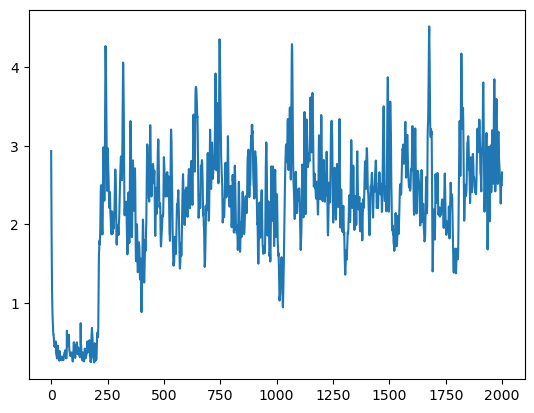

In [14]:
e_sd_kecd.saveExpt()
plt.plot(e_sd_kecd.rmse)
#dap.plot_pab(e_sd_kecd, plot_states=True)

### do my embeddings look reasonable? let's take a look:

In [5]:
embs = np.load('multivar_emb.npz')
embs_l = np.load('multivar_emb_large.npz')
#for key in embs:
#    print(f'{key} with shape {embs[key].shape}')
x_emb = embs['x_emb']
y_emb = embs['y_emb']
evec_x = embs['evec_x']
evec_y = embs['evec_y']
eval_x = embs['eval_x']
eval_y = embs['eval_y']
bwx = embs['bwx']
bwy = embs['bwy']
x_train = embs['x_train']
y_train = embs['y_train']
a_train_x = embs['a_train_x']
a_train_y = embs['a_train_y']


lx_emb = embs_l['x_emb']
ly_emb = embs_l['y_emb']
levec_x = embs_l['evec_x']
levec_y = embs_l['evec_y']
leval_x = embs_l['eval_x']
leval_y = embs_l['eval_y']
lbwx = embs_l['bwx']
lbwy = embs_l['bwy']
lx_train = embs_l['x_train']
ly_train = embs_l['y_train']
la_train_x = embs_l['a_train_x']
la_train_y = embs_l['a_train_y']

In [6]:
def quadratic(x,a,b,c):
    return a*x*x + b*x + c

def plot_state_and_embs(n, ev1, ev2, large_only, x_or_y, sample_nystrom, a, b, c, find_nearest):
    fig, axs = plt.subplots(1,2, figsize=(10,5))

    if x_or_y == 'x':
        if not large_only:
            plotme_train = x_train
            plotme_embs = x_emb
            vec = evec_x
            val = eval_x
            bw = bwx
            a_train = a_train_x
        else:
            plotme_train = lx_train
            plotme_embs = lx_emb
            vec = levec_x
            val = leval_x
            bw = lbwx
            a_train = la_train_x
    else:
        if not large_only:
            plotme_train = y_train
            plotme_embs = y_emb
            vec = evec_y
            val = eval_y
            bw = bwy
            a_train = a_train_y
        else:
            plotme_train = ly_train
            plotme_embs = ly_emb
            vec = levec_y
            val = leval_y
            bw = lbwy
            a_train = la_train_y

    a_train = np.asarray(a_train).squeeze()

    ## plot training data points

    if x_or_y == 'x':
        axs[0].plot(plotme_train[:,n], c='C1', label=f'training point {n}')
        axs[0].set_ylim(-10,20)
    else:
        axs[0].scatter(plotme_train[:,n], 0, c='C1', label=f'training point {n}')
        axs[0].plot([1e-3, 2], [0,0], c='C1')
        axs[0].set_xlim(1e-3,2)
        axs[0].set_xscale('log')
        
    ## plot DM embeddings
        
    axs[1].scatter(plotme_embs[ev1], plotme_embs[ev2], s=2)
    axs[1].scatter(plotme_embs[ev1, n], plotme_embs[ev2,n], c='C1', label='training embedding')
    axs[1].set_xlabel(f'EV {ev1}')
    axs[1].set_ylabel(f'EV {ev2}')

    ## plot OOSE via nystrom from sample point

    if sample_nystrom:
        if x_or_y == 'x':
            sample = quadratic(np.arange(33), a,b,c).reshape(1,-1)
            oose_emb = diff_map_ext_nystrom(sample,
            plotme_train.T,
            vec,
            val,
            a_train,
            bw,
            2401, 
            33)

            axs[0].plot(sample[0], c='black', label='OOSE input')
            sample_emb = (oose_emb * val).T
            axs[1].scatter(sample_emb[ev1], sample_emb[ev2], c='black', label='OOSE emb')

            if find_nearest:
                ind = np.argmin(np.sum((sample_emb - plotme_embs) ** 2, axis=0))
                axs[0].plot(plotme_train[:,ind], c='C3', label=f'training closest to OOSE: {ind}')
                axs[1].scatter(plotme_embs[ev1,ind], plotme_embs[ev2, ind], c='C3', label=f'emb of training closest to OOSE: {ind}')

        else:
            
            oose_emb = diff_map_ext_nystrom(np.array([[a]]),
            plotme_train.T,
            vec,
            val,
            a_train,
            bw,
            2401, 
            1)

            axs[0].scatter(a, 0, c='black')
            sample_emb = (oose_emb * val).T
            axs[1].scatter(sample_emb[ev1], sample_emb[ev2], c='black')
            
            if find_nearest:
                ind = np.argmin(np.sum((sample_emb - plotme_embs) ** 2, axis=0))
                axs[0].scatter(plotme_train[:,ind], 0, c='C3', label=f'training closest to OOSE: {ind}')
                axs[1].scatter(plotme_embs[ev1,ind], plotme_embs[ev2, ind], c='C3', label=f'emb of training closest to OOSE: {ind}')
            

    ## clean things up
    
    plt.tight_layout()
    axs[0].legend(loc=1)
    axs[1].legend(loc=1)
    

interact(
    plot_state_and_embs,
    n=IntSlider(min=0, max=23999, step=1, value=0),
    ev1=IntSlider(min=0, max=50, step=1, value=2),
    ev2=IntSlider(min=0, max=50, step=1, value=3),
    large_only=Checkbox(options=['True','False'], description='Training on large only:'),
    sample_nystrom=Checkbox(options=['True','False'], description='OOSE Point?:'),
    find_nearest=Checkbox(options=['True','False'], description='Nearest training point to OOS input:'),
    x_or_y = RadioButtons(options=['x','y'], description='x or y?'),
    a = FloatSlider(min=-1, max=1, step=0.01, value=0),
    b = FloatSlider(min=-10, max=10, step=0.01, value=0),
    c = FloatSlider(min=-10, max=20, step=0.1, value=0),
);

#nystrom ext constructed curves!

interactive(children=(IntSlider(value=0, description='n', max=23999), IntSlider(value=2, description='ev1', ma…

### this doesn't seem very good (see below)

## OK - what about assimilating these obs directly, with knowledge of the correct forward operator?

### After fixing some numerical stuff in the LPF, I am tracking experiments that JP has come up with for this case. Good parameters for this experiment seem to be obf = 10, small_win=4, roi=0.02 (double what it was for the other experiments). The output of that experiment (and the same one with roi=0.015) are in data/experiments/scale-sep

In [18]:
print(f'starting experiment {e_name}')
#bw = 0.02
#knn = 0.1
klb=0.0
obfs = np.array([10])
small_wins = np.array([4])
roi = 0.2
obf=10
small_win=4

#obfs = np.array([10])
#small_wins = np.array([4])
#rois = np.array([0.015])

e_split_true = dap.Expt(f'e_roi_{roi}', {'expt_flag': 1,
                       'model_flag':2,
                       'model_params': params,
                       'localize':1,
                       'obf': obf,
                       'seed': 58,
                       'h_flag': 3,
                       'roi': roi,
                       'Nt_eff': 0.8,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_small_sc,
                       'prescribed_obs_err_params': poep_small_sc,
                       'save_keest_pab':1,
                       'small_win': small_win,
                       'kddm_flag': 1,
                       'Ne':80,
                       'T': 2000,
                       'saveForecastEns': True,
                       'saveEnsMean': True})

e_name = 'l05-noda-split-c25'
e_split_noda = dap.Expt(e_name, {'expt_flag': 2,
                       'model_flag':2,
                       'model_params': params,
                       'localize':1,
                       'seed': 58,
                       'h_flag': 3,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'Ne':80,
                       'T': 2000,
                       'split_l05_state': False,
                       'saveForecastEns': True,
                       'saveEnsMean': True,
                       'debug_nle_noDA': False})

starting experiment l05-kecd-split_full


In [20]:
dap.runDA(e_split_noda)
dap.runDA(e_split_true)
#e_split_true.saveExpt()
#e_split_noda.saveExpt()

DB: RMSE at time 0: 3.872174724839312
DB: RMSE at time 100: 4.185142846350444
DB: RMSE at time 200: 5.212547119857809
DB: RMSE at time 300: 5.199200220931743
DB: RMSE at time 400: 5.182006972852713
DB: RMSE at time 500: 5.397948724134631
DB: RMSE at time 600: 4.748407559727752
DB: RMSE at time 700: 4.456681796069806
DB: RMSE at time 800: 4.695144419600951
DB: RMSE at time 900: 4.078903298333769
DB: RMSE at time 1000: 4.838352466867609
DB: RMSE at time 1100: 4.356524719459139
DB: RMSE at time 1200: 4.766310411386326
DB: RMSE at time 1300: 5.075426371446556
DB: RMSE at time 1400: 4.920128977065486
DB: RMSE at time 1500: 4.393339966190953
DB: RMSE at time 1600: 4.927663987155667
DB: RMSE at time 1700: 4.818567200311909
DB: RMSE at time 1800: 4.4500523358907955
DB: RMSE at time 1900: 4.270944620289995


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 3.7408952144517893
DB: RMSE at time 100: 5.042518706838148
DB: RMSE at time 200: 6.344957624670415
DB: RMSE at time 300: 4.154182506027516
DB: RMSE at time 400: 5.071697955087843
DB: RMSE at time 500: 5.2489145949158775
DB: RMSE at time 600: 5.24970709926401
DB: RMSE at time 700: 5.738782987265605
DB: RMSE at time 800: 6.317932919569978
DB: RMSE at time 900: 5.1649568786974225
DB: RMSE at time 1000: 5.625078152275144
DB: RMSE at time 1100: 4.243736170704382
DB: RMSE at time 1200: 3.362780229586687
DB: RMSE at time 1300: 4.34523254528932
DB: RMSE at time 1400: 4.126495788076251
DB: RMSE at time 1500: 5.561331032502335
DB: RMSE at time 1600: 6.742670826536028
DB: RMSE at time 1700: 4.7163806600532086
DB: RMSE at time 1800: 4.912270216856603
DB: RMSE at time 1900: 6.647632974481802


'completed'

In [22]:
e_split_true = dap.loadExpt('data/experiments/scale-sep/e_roi_0.02.expt')
e_split_noda = dap.loadExpt('data/experiments/scale-sep/l05-noda-split-c25.expt')

def plot_scale_sep(t, ne, lowc, show_small_scales, show_fens_member, show_noda_ens, show_obs, show_aens_member, show_truth, show_ens_mean, show_noda_mean):

    if lowc:
        xf = e_split_true_lowc.x_fore_ens
        xa = e_split_true_lowc.x_ens
        xt = e_split_true_lowc.getStates()[1]
        Y = e_split_true_lowc.getStates()[2]
        xam = e_split_true_lowc.x_ensmean
    else:
        xf = e_split_true.x_fore_ens
        xa = e_split_true.x_ens
        xt = e_split_true.getStates()[1]
        Y = e_split_true.getStates()[2]
        xam = e_split_true.x_ensmean

    if show_truth:
        plt.plot(xt[:,t], c='k', label='truth')
        if show_obs:
            plt.scatter(np.arange(0,480,obf), Y[:,t,:], c='k', s=6)

    if show_fens_member:
        xf_smallscale = deconstruct_Z_circulant(xf[:,:,t])[1]
        hx = dap.MISC.h_weighted_mat(xf_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hx[:, ne], c='r', s=6)
        plt.plot(xf[:,ne,t], c='r', label=f'bg ens member {ne}')
        
    if show_aens_member:
        xa_smallscale = deconstruct_Z_circulant(xa[:,:,t])[1]
        hxa = dap.MISC.h_weighted_mat(xa_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hxa[:, ne], c='blue', s=6)
        plt.plot(xa[:,ne,t], c='blue', label=f'post ens member {ne}')

    if show_small_scales:
        if show_truth:
            xt_smallscale = deconstruct_Z_circulant(xt)[1]
            plt.plot(xt_smallscale[:,t], c='k', linewidth=1)
        if show_fens_member:
            plt.plot(xf_smallscale[:,ne], c='r', linewidth=1)
        if show_aens_member:
            plt.plot(xa_smallscale[:,ne], c='blue', linewidth=1)

    if show_ens_mean:
        plt.plot(xam[:,t], label='ens mean')
        
    if show_noda_mean:
        if lowc:
            plt.plot(e_split_noda_lowc.x_ensmean[:,t], label='noda mean')
        else:
            plt.plot(e_split_noda.x_ensmean[:,t], label='noda mean')

    if show_noda_ens:
        xa_noda = e_split_noda.x_ens
        plt.plot(xa_noda[:,ne,t], c='magenta', label = f'noda member {ne}')
        
        
    
    plt.legend(loc=4)
    plt.ylim(-10, 16)


interact(
    plot_scale_sep,
    t=IntSlider(min=1, max=1999, step=1, value=0),
    ne=IntSlider(min=1, max=79, step=1, value=0),
    show_small_scales=Checkbox(options=['True','False'], description='plot small scale:'),
    lowc=Checkbox(options=['True','False'], description='Low coupling:'),
    show_obs=Checkbox(options=['True','False'], description='plot obs space quantities:'),
    show_fens_member=Checkbox(options=['True','False'], description='plot forecast ensemble member:'),
    show_aens_member=Checkbox(options=['True','False'], description='plot analysis ensemble member:'),
    show_ens_mean=Checkbox(options=['True','False'], description='plot ensemble mean:'),
    show_noda_mean=Checkbox(options=['True','False'], description='plot noda mean:'),
    show_noda_ens=Checkbox(options=['True','False'], description='plot noda ens members:'),
    show_truth=Checkbox(options=['True','False'], description='plot truth and obs:', value=True),
);
print(e_split_true.x_ensmean.shape)


interactive(children=(IntSlider(value=1, description='t', max=1999, min=1), IntSlider(value=1, description='ne…

(480, 2000)


Known h(x) RMSE:
5.154747898976831
No DA RMSE:
4.69293128908588
KECD RMSE:
2.464383059521737


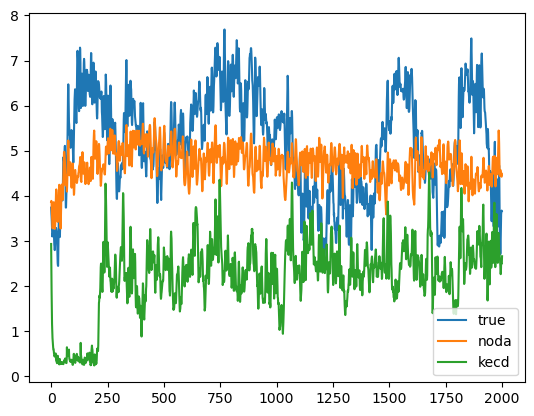

In [21]:
#m_long_mat = loadmat('data/experiments/scale-sep/l05_c25.mat')
plt.plot(e_split_true.rmse, label='true')
plt.plot(e_split_noda.rmse, label='noda')
plt.plot(e_sd_kecd.rmse, label='kecd')

print('Known h(x) RMSE:')
print(e_split_true.rmse[500:].mean())
print('No DA RMSE:')
print(e_split_noda.rmse[500:].mean())
print('KECD RMSE:')
print(e_sd_kecd.rmse[500:].mean())

plt.legend()

## INITIAL CONSTRUCTION OF SMALL STATE FORWARD OPERATOR/PICKING OUT TRAINING X INTERVALS

In [124]:
def h_weighted_mat(Y, h, w=3):
    Y = np.asarray(Y)
    N,k = Y.shape
    
    # 1. Determine the center indices for each step
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    
    # 2. Create the window offsets
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 3. Compute all target indices using broadcasting and modulo for periodicity
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    
    # 4. Construct the transformation matrix W of shape (M, N)
    M = len(centers)
    W = np.zeros((M, N))
    
    # Row-by-row, add 1 to the positions specified by target_indices
    row_indices = np.arange(M)[:, np.newaxis]
    np.add.at(W, (row_indices, target_indices), 1)
    
    # 5. The single matrix operation applied to |Y|
    return W @ np.abs(Y)

def x_slices(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine the center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 2. Compute periodic target indices
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    M, window_size = target_indices.shape
    
    # 3. Construct the Selection Matrix P of shape (M * window_size, N)
    total_extracted_elements = M * window_size
    P = np.zeros((total_extracted_elements, N))
    
    # Map each position in the flattened output to its corresponding index in X
    row_indices = np.arange(total_extracted_elements)
    col_indices = target_indices.ravel() # Flatten the target indices
    P[row_indices, col_indices] = 1
    
    # 4. Apply the matrix operation and reshape into the final matrix grid
    flat_slices = P @ X
    return flat_slices.reshape(M, window_size)

import numpy as np

def periodic_window_context(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (1, 2w + 1)
    
    # 2. Compute periodic target indices
    targets = (centers + offsets) % N           # Shape: (M, 2w + 1)
    M = len(centers)
    
    # 3. Construct the Context Selection Matrix P of shape (M * N, N)
    # Initialize the entire matrix with np.nan
    P = np.full((M * N, N), np.nan)
    
    # Calculate which global row indices in P correspond to valid window placements
    step_indices = np.arange(M)[:, np.newaxis]
    rows = (step_indices * N + targets).ravel()
    cols = targets.ravel()
    
    # For active rows, initialize them to 0, then set the target column to 1
    P[rows, :] = 0
    P[rows, cols] = 1
    
    # 4. Perform the single matrix multiplication and reshape to (M, N)
    flat_context = P @ X
    return flat_context.reshape(M, N)

def deconstruct_Z_circulant(Zn_matrix, I=12):
    Zn_matrix = np.asarray(Zn_matrix)
    Nx, k_cols = Zn_matrix.shape
    I = int(I)
    
    if I > 1:
        alpha = (3*I*I + 3)/(2*I*I*I + 4*I)
        beta = (2*I*I + 1)/(I*I*I*I + 2*I*I)
        
        # 1. Create the base filter weights
        offsets = np.arange(-I, I + 1)
        weights = alpha - beta * np.abs(offsets)
        weights[0] /= 2
        weights[-1] /= 2
        
        # 2. Map weights to a baseline row of length Nx using periodic modulo
        base_row = np.zeros(Nx)
        np.add.at(base_row, offsets % Nx, weights)
        
        # 3. Generate the Nx x Nx Circulant Transformation Matrix
        rows = np.arange(Nx)[:, np.newaxis]
        cols = np.arange(Nx)
        C = base_row[(cols - rows) % Nx]
        
        # 4. Apply the single matrix multiplication to all columns at once
        # (Nx x Nx) @ (Nx x k_cols) -> (Nx x k_cols)
        Xn = C @ Zn_matrix
        Yn = Zn_matrix - Xn
    else:
        Xn = Zn_matrix.copy()
        Yn = np.zeros_like(Zn_matrix)
        
    return Xn, Yn

### demo plotting - see file location

In [82]:
#for num in range(120):
#   xs = periodic_window_context(X, 4, 10)
#   plt.plot(ens1, linewidth=2, c='k')
#   plt.plot(X, c='red')
#   plt.plot(Y)
#   plt.plot(xs[num], linewidth=6, c='red')
#   plt.plot((num*4, num*4), (0,2*hy[num]), linewidth=1, c='C1')
#   plt.scatter(num*4, 2*hy[num], c='C1')
#   plt.savefig(f'../figs/l05-multiscale/demo-l05-multiscale-{num:03}.png')
#   plt.close()

In [25]:
#_split_true = dap.Expt(f'e_roi_{roi}', {'expt_flag': 1,
#                      'model_flag':2,
#                      'model_params': params,
#                      'localize':1,
#                      'obf': obf,
#                      'seed': 58,
#                      'h_flag': 3,
#                      'roi': roi,
#                      'Nt_eff': 0.8,
#                      'used_obs_err': 0,
#                      'prescribed_obs_err': 0,
#                      'used_obs_err_params': uoep_small_sc,
#                      'prescribed_obs_err_params': poep_small_sc,
#                      'save_keest_pab':1,
#                      'small_win': small_win,
#                      'kddm_flag': 1,
#                      'Ne':80,
#                      'T': 2000,
#                      'saveForecastEns': True,
#                      'saveEnsMean': True})
e_split_true.getParam('roi')

np.float64(0.02)